In [6]:
import pandas as pd

In [7]:
sentiment = pd.read_csv("fear_greed_index.csv")
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [8]:
sentiment.shape

(2644, 4)

In [9]:
trader = pd.read_csv("historical_data.csv")
trader.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [10]:
trader.shape

(211224, 16)

In [12]:
sentiment.columns, trader.columns

(Index(['timestamp', 'value', 'classification', 'date'], dtype='object'),
 Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
        'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
        'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
        'Timestamp'],
       dtype='object'))

In [14]:
trader['Timestamp IST'] = pd.to_datetime(trader['Timestamp IST'], format='%d-%m-%Y %H:%M')
trader['date'] = trader['Timestamp IST'].dt.date
trader['time'] = trader['Timestamp IST'].dt.time
display(trader.head())

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,time
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,22:50:00
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,22:50:00
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,22:50:00
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,22:50:00
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,22:50:00


### Merging Trader Data with Market Sentiment
We will convert the 'date' column in the sentiment dataframe to a datetime object to match the format in the trader dataframe, and then perform an inner merge.

In [17]:
import datetime

sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date

merged_df = pd.merge(trader, sentiment, on='date', how='inner')

print(f"Merged DataFrame Shape: {merged_df.shape}")
display(merged_df.head())

Merged DataFrame Shape: (211218, 21)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,...,Order ID,Crossed,Fee,Trade ID,Timestamp,date,time,timestamp,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,22:50:00,1733117400,80,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,22:50:00,1733117400,80,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,22:50:00,1733117400,80,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,22:50:00,1733117400,80,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,22:50:00,1733117400,80,Extreme Greed


### Basic Correlation Analysis
Let's take a quick look at the correlation between the sentiment 'value' and 'Closed PnL' to see if there's an immediate relationship.

In [18]:
correlation = merged_df[['value', 'Closed PnL']].corr()
display(correlation)

,value,Closed PnL
value,1.000000,0.008121
Closed PnL,0.008121,1.000000


### Sentiment Analysis: PnL by Classification
We will group the data by the sentiment classification to see the average and total 'Closed PnL' for each market mood.

/tmp/ipykernel_7723/3312299972.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='classification', y='mean', data=sentiment_pnl, palette='coolwarm')


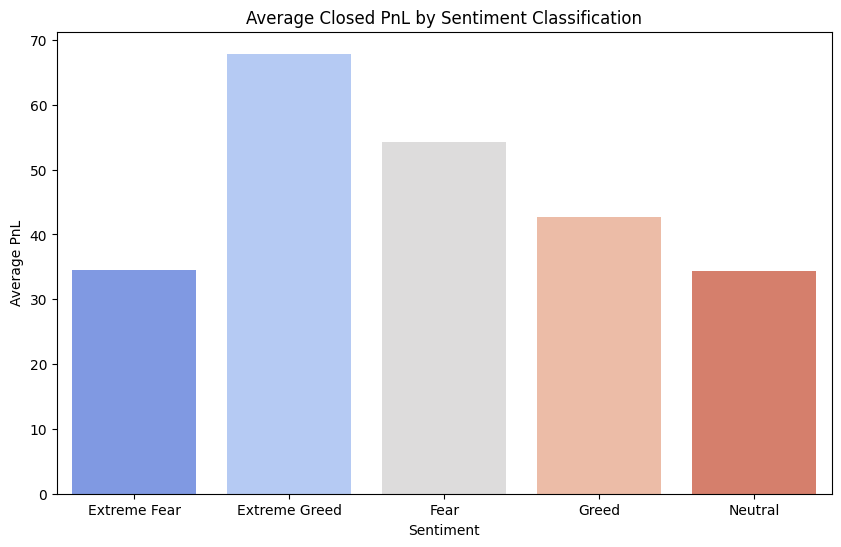

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Aggregate PnL by sentiment classification
sentiment_pnl = merged_df.groupby('classification')['Closed PnL'].agg(['mean', 'sum', 'count']).reset_index()

# Visualization 1: Average PnL by Sentiment
plt.figure(figsize=(10, 6))
sns.barplot(x='classification', y='mean', data=sentiment_pnl, palette='coolwarm')
plt.title('Average Closed PnL by Sentiment Classification')
plt.ylabel('Average PnL')
plt.xlabel('Sentiment')
plt.show()

### Sentiment Value vs. Trade Volume
Does higher greed lead to more trades? Let's check the relationship between the sentiment value and the number of transactions.

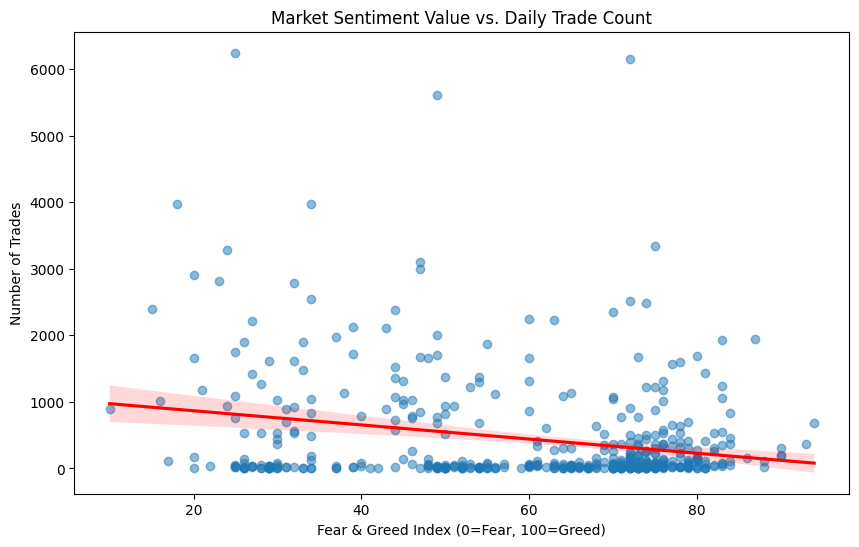

In [20]:
daily_activity = merged_df.groupby('date').agg({'value': 'first', 'Trade ID': 'count'}).rename(columns={'Trade ID': 'trade_count'})

plt.figure(figsize=(10, 6))
sns.regplot(x='value', y='trade_count', data=daily_activity, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Market Sentiment Value vs. Daily Trade Count')
plt.xlabel('Fear & Greed Index (0=Fear, 100=Greed)')
plt.ylabel('Number of Trades')
plt.show()

### Win Rate by Sentiment Classification
A key performance metric is the win rate. Let's see if the market sentiment affects the probability of a trade being profitable.

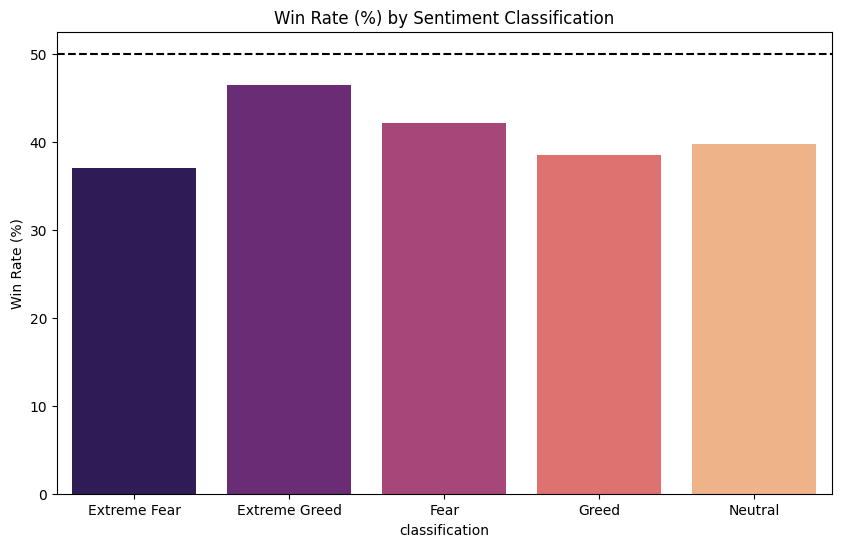

In [21]:
merged_df['is_win'] = merged_df['Closed PnL'] > 0
win_rate_analysis = merged_df.groupby('classification')['is_win'].mean().reset_index()
win_rate_analysis['win_rate_pct'] = win_rate_analysis['is_win'] * 100

plt.figure(figsize=(10, 6))
sns.barplot(x='classification', y='win_rate_pct', data=win_rate_analysis, palette='magma', hue='classification', legend=False)
plt.title('Win Rate (%) by Sentiment Classification')
plt.ylabel('Win Rate (%)')
plt.axhline(50, color='black', linestyle='--')
plt.show()

### Cumulative PnL Over Time vs. Sentiment
let's look at the equity curve. We'll plot the cumulative PnL over time and overlay the sentiment value to see if drawdowns or peaks align with specific market moods.

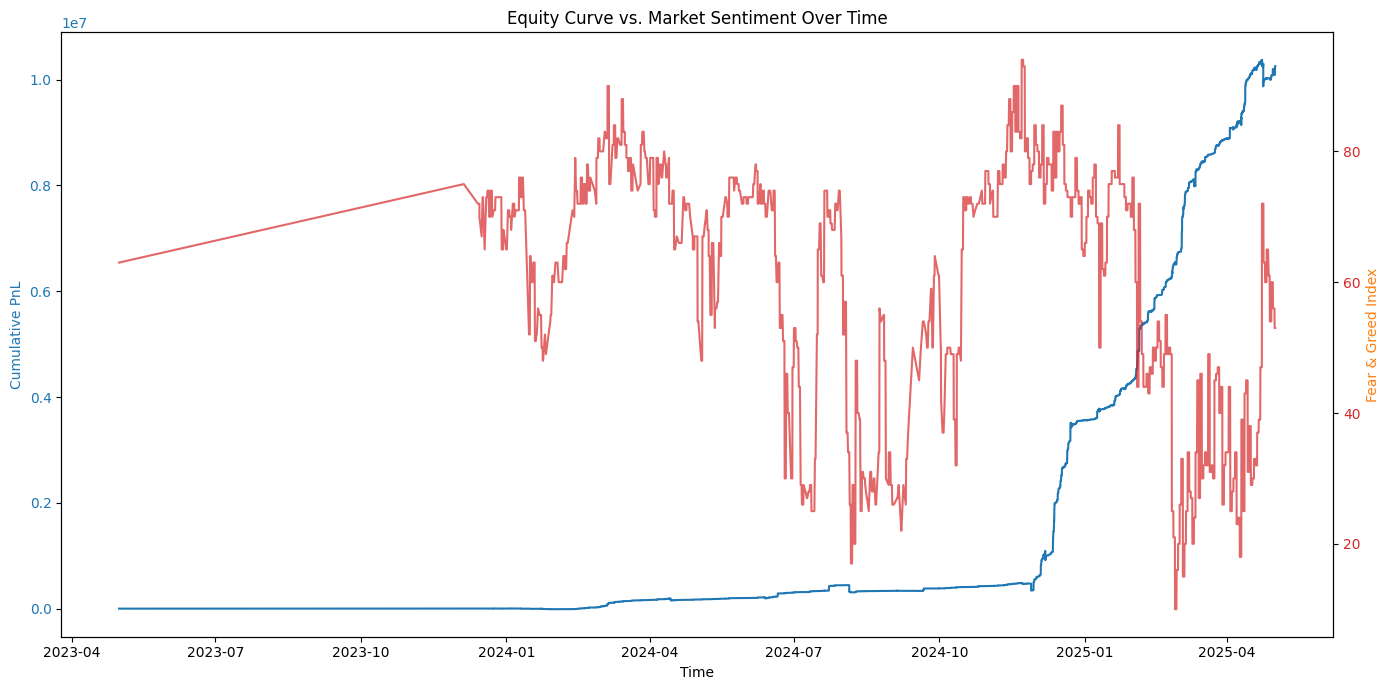

In [24]:
time_series = merged_df.sort_values('Timestamp IST').copy()
time_series['cumulative_pnl'] = time_series['Closed PnL'].cumsum()

fig, ax1 = plt.subplots(figsize=(14, 7))

# Plot Cumulative PnL
ax1.set_xlabel('Time')
ax1.set_ylabel('Cumulative PnL', color='tab:blue')
ax1.plot(time_series['Timestamp IST'], time_series['cumulative_pnl'], color='tab:blue', label='Equity Curve')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Instantiate a second axes that shares the same x-axis
ax2 = ax1.twinx()
ax2.set_ylabel('Fear & Greed Index', color='tab:orange')
ax2.plot(time_series['Timestamp IST'], time_series['value'], color='tab:red', alpha=0.7, label='Sentiment Value')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('Equity Curve vs. Market Sentiment Over Time')
fig.tight_layout()
plt.show()

### Profitability by Coin and Sentiment
Let's see if certain coins are 'sentiment-sensitive'. We'll visualize the top 10 coins by total PnL and how they behave across sentiment categories.

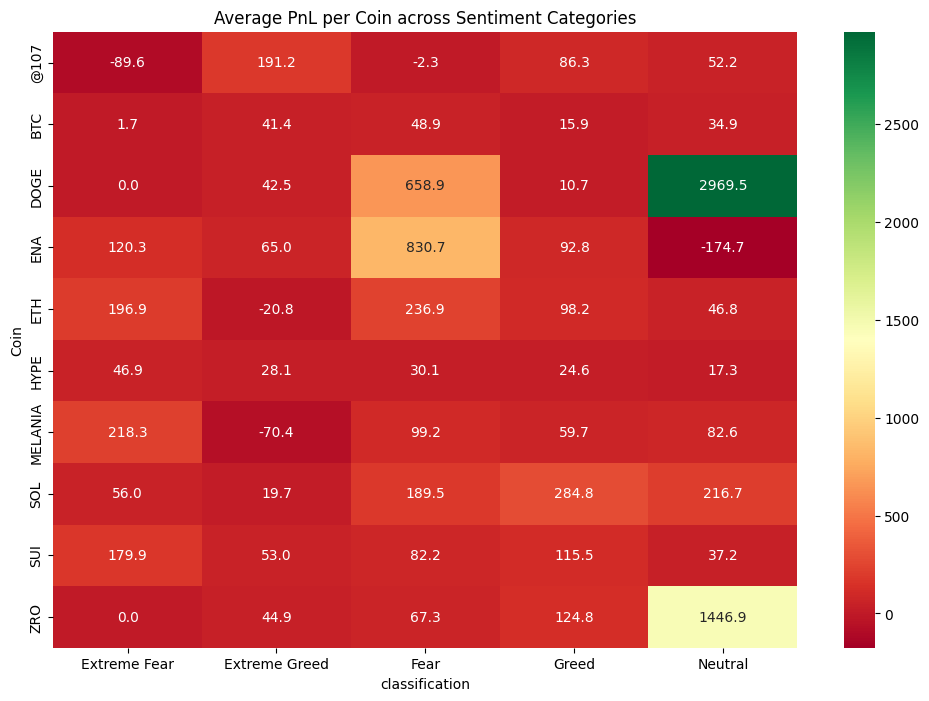

In [26]:
top_coins = merged_df.groupby('Coin')['Closed PnL'].sum().nlargest(10).index
coin_sentiment = merged_df[merged_df['Coin'].isin(top_coins)].groupby(['Coin', 'classification'])['Closed PnL'].mean().unstack()

plt.figure(figsize=(12, 8))
sns.heatmap(coin_sentiment, annot=True, fmt='.1f', cmap='RdYlGn')
plt.title('Average PnL per Coin across Sentiment Categories')
plt.show()

### Predictive Modeling for Smarter Strategies
We will build a model to predict `is_win`. Features will include the sentiment value, classification, trade side, and the coin being traded.

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# Data Preparation
# We'll use a subset of columns as features
features = ['Side', 'value', 'classification', 'Coin']
X = merged_df[features].copy()
y = merged_df['is_win'].astype(int)

# Encode categorical variables
le = LabelEncoder()
for col in ['Side', 'classification', 'Coin']:
    X[col] = le.fit_transform(X[col].astype(str))

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train a Random Forest Classifier
model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
model.fit(X_train, y_train)

# Evaluate the model
y_pred = model.predict(X_test)
print("Model Performance Metrics:")
print(classification_report(y_test, y_pred))

Model Performance Metrics:
              precision    recall  f1-score   support

           0       0.81      0.88      0.85     24848
           1       0.81      0.71      0.76     17396

    accuracy                           0.81     42244
   macro avg       0.81      0.80      0.80     42244
weighted avg       0.81      0.81      0.81     42244



### Feature Importance
Let's see which factors the model finds most useful for predicting a winning trade.

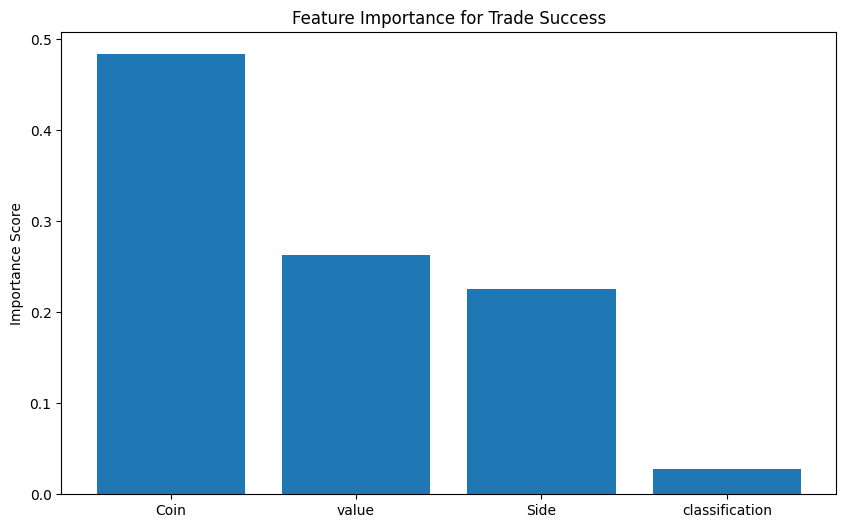

In [28]:
import numpy as np

importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Feature Importance for Trade Success")
plt.bar(range(X.shape[1]), importances[indices], align="center")
plt.xticks(range(X.shape[1]), [features[i] for i in indices])
plt.ylabel("Importance Score")
plt.show()

### Future Prediction Interface
This function allows you to input real-time market data to get a success prediction from the model.

In [29]:
def predict_trade_success(side, coin, fear_greed_value):
    # Helper to map sentiment value to classification similar to the dataset
    if fear_greed_value <= 25: class_str = 'Extreme Fear'
    elif fear_greed_value <= 45: class_str = 'Fear'
    elif fear_greed_value <= 55: class_str = 'Neutral'
    elif fear_greed_value <= 75: class_str = 'Greed'
    else: class_str = 'Extreme Greed'

    # Create a DataFrame for the single trade
    input_data = pd.DataFrame([{
        'Side': side,
        'value': fear_greed_value,
        'classification': class_str,
        'Coin': coin
    }])

    try:
        for col in ['Side', 'classification', 'Coin']:

            input_data[col] = le.fit_transform(input_data[col].astype(str))

        prediction = model.predict(input_data)[0]
        probability = model.predict_proba(input_data)[0][1]

        result = "PROFITABLE" if prediction == 1 else "NOT PROFITABLE"
        print(f"Prediction for {side} {coin} at Sentiment {fear_greed_value}: {result}")
        print(f"Confidence: {probability:.2%}")
    except Exception as e:
        print(f"Error in prediction: {e}. Ensure the Coin name matches the dataset format.")

# Example usage: Predicting a BUY for BTC when the market is at 20 (Extreme Fear)
predict_trade_success('BUY', 'BTC', 20)

Prediction for BUY BTC at Sentiment 20: NOT PROFITABLE
Confidence: 0.98%


### Temporal Analysis: Performance by Day and Hour
Trading behavior often follows weekly and daily cycles. Let's extract the day of the week and the hour to see if they correlate with PnL.

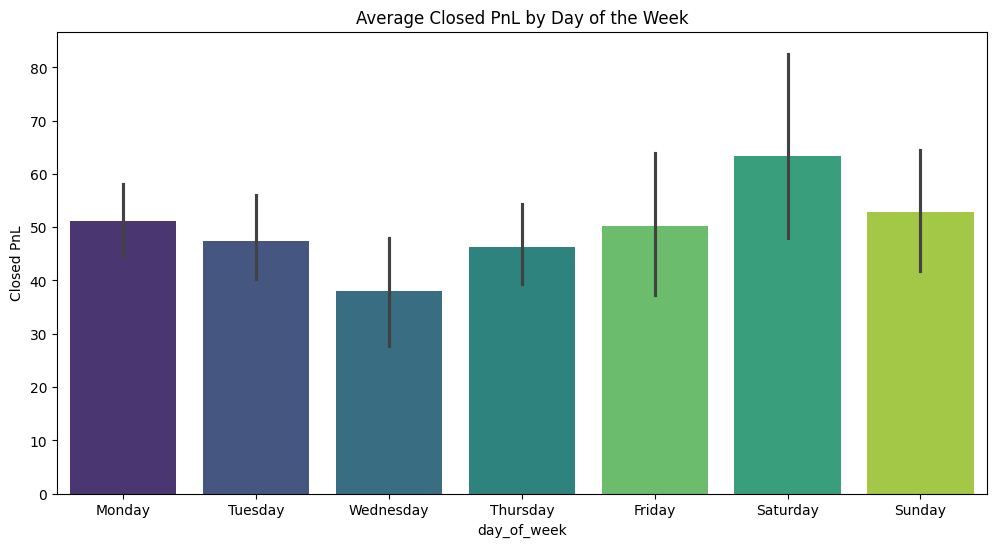

In [30]:
merged_df['day_of_week'] = pd.to_datetime(merged_df['date']).dt.day_name()
merged_df['hour'] = merged_df['Timestamp IST'].dt.hour

# Visualization: Average PnL by Day of Week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
plt.figure(figsize=(12, 6))
sns.barplot(x='day_of_week', y='Closed PnL', data=merged_df, order=day_order, palette='viridis', hue='day_of_week', legend=False)
plt.title('Average Closed PnL by Day of the Week')
plt.show()

### Saving the Model and Encoder
We use `joblib` to persist the model and the preprocessing tools so they can be reused without retraining.

In [35]:
import joblib

# Save the model
joblib.dump(model, 'models/trading_model.joblib')
joblib.dump(le, 'models/label_encoder.joblib')


['models/label_encoder.joblib']